<a href="https://colab.research.google.com/github/saujanyaera/Dog_VS_Cat_Classifier/blob/main/dog_Vs_cat.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1 Mount drive
from google.colab import drive
drive.mount('/content/drive')

# 2 Setup kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# 3 Download dataset
!kaggle datasets download -d tongpython/cat-and-dog

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

In [ ]:
!kaggle datasets download -d tongpython/cat-and-dog

In [ ]:
!unzip cat-and-dog.zip -d datasets

In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import regularizers

In [ ]:
# generators
train_ds=keras.utils.image_dataset_from_directory(
directory='/content/datasets/training_set/training_set',
labels='inferred',
# labels the images to the numerical values
label_mode='int',
batch_size=32,
# automatically goes to 32 images to the RAM
image_size=(256,256)
)

validation_ds=keras.utils.image_dataset_from_directory(
directory='/content/datasets/test_set/test_set',
labels='inferred',
label_mode='int',
batch_size=32,
image_size=(256,256)
)
class_names = train_ds.class_names
print("Class names:", class_names)

In [ ]:
# normalization

def process(image, label):
  image=tf.cast(image/255., tf.float32)
  return image, label

train_ds=train_ds.map(process)
# .map processe the function in every images

validation_ds=validation_ds.map(process)



In [ ]:
model=Sequential()

model.add(Conv2D(32, kernel_size=(3,3), padding='valid', activation='relu', kernel_regularizer=regularizers.l2(0.001), input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))
model.add(Conv2D(64, kernel_size=(3,3), padding='valid', activation='relu',kernel_regularizer=regularizers.l2(0.001) ))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid',))
model.add(Conv2D(128, kernel_size=(3,3), padding='valid', activation='relu',kernel_regularizer=regularizers.l2(0.001) ))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Flatten())

model.add(Dense(128, activation='relu',kernel_regularizer=regularizers.l2(0.001)))
model.add(Dropout(0.1))
model.add(Dense(64, activation='relu',kernel_regularizer=regularizers.l2(0.001)))
model.add(Dropout(0.1))
model.add(Dense(1, activation='sigmoid'))



In [ ]:
es=EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True
)

In [ ]:
model.summary()

In [ ]:
from keras.src.backend.torch import optimizers
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# loss and accuracy in trainig data
# val_Accuracy and val_loss in testing data

In [ ]:
history=model.fit(train_ds, epochs=20, validation_data=validation_ds, callbacks=[es])

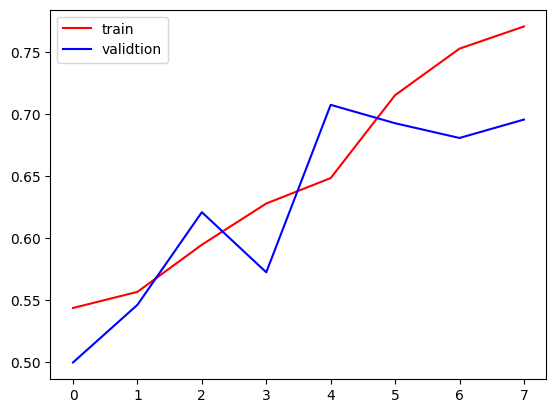

In [71]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], color='red', label='train')
plt.plot(history.history['val_accuracy'], color='blue', label='validtion')
plt.legend()
plt.show()

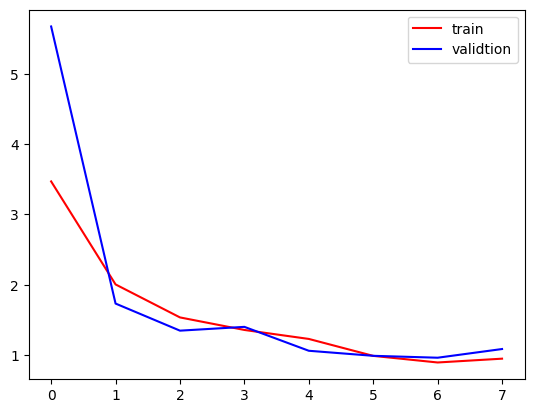

In [72]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'], color='red', label='train')
plt.plot(history.history['val_loss'], color='blue', label='validtion')
plt.legend()
plt.show()

In [ ]:
import cv2



In [73]:
img_test=cv2.imread('/content/dog1.jpg')

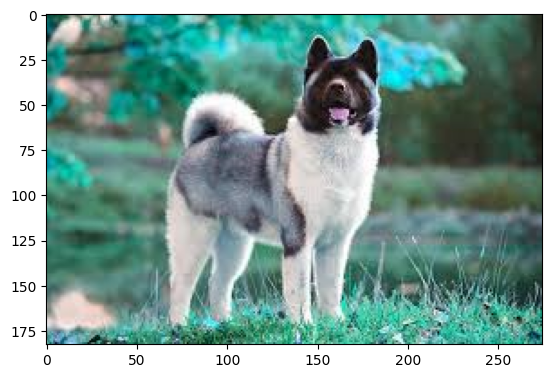

In [74]:
plt.imshow(img_test)

In [ ]:
img_test.shape

In [ ]:
img_test=cv2.resize(img_test, (256,256))

In [ ]:
test_input=img_test.reshape((1,256,256,3))

In [76]:

pred = model.predict(test_input)
print(pred)
# 0 for dog and 1 for cat

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
[[0.]]


In [86]:
img_test=cv2.imread('/content/cat.avif')

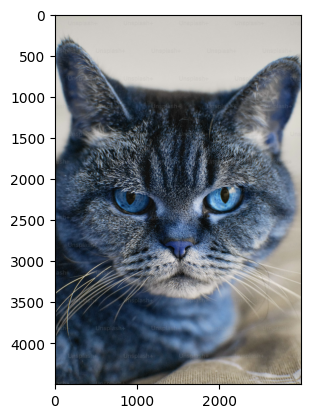

In [87]:
plt.imshow(img_test)

In [88]:
img_test=cv2.resize(img_test, (256,256))

In [89]:
test_input=img_test.reshape((1,256,256,3))

In [90]:

pred = model.predict(test_input)
print(pred)
# 0 for dog and 1 for cat

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
[[1.]]
